model_training_evaluation

# Entrenamiento y evaluacion de modelos

Este notebook toma los datos ya transformados (mediante las funciones `cargarDatos()` y `ft_engineering()` definidas previamente en `ft_engineering.ipynb` y reutilizadas aqui) para entrenar y evaluar los primeros modelos supervisados de clasificacion binaria, prediciendo la variable objetivo `Pago_atiempo` (1 = paga a tiempo, 0 = no paga a tiempo).



## Modelos a entrenar

- **Regresion Logistica**: modelo lineal simple, usado como linea base.
- **Arbol de Decision**: captura relaciones no lineales entre variables.
- **Random Forest**: combina multiples arboles de decision para mejorar la robustez y reducir el sobreajuste.

Cada modelo se entrena con los mismos datos de entrenamiento (`X_train_processed`, `y_train`) y se evalua sobre el mismo conjunto de prueba (`X_test_processed`, `y_test`) para poder comparar su desempeno de forma justa.

In [1]:
import pandas as pd
from sklearn.preprocessing import FunctionTransformer, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


def cargarDatos():
    df = pd.read_csv('../../Base_de_datos.csv', sep=';')

    df['tendencia_ingresos'] = df['tendencia_ingresos'].fillna('Desconocido')
    categorias_validas = ['Creciente', 'Decreciente', 'Estable']
    df.loc[~df['tendencia_ingresos'].isin(categorias_validas), 'tendencia_ingresos'] = 'Desconocido'

    df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'], format='%d/%m/%Y %H:%M')
    df['fecha_prestamo'] = df['fecha_prestamo'].dt.strftime('%Y%m%d').astype(int)

    return df


def ft_engineering(X):
    num_features = X.select_dtypes('number').columns
    ordinal_features = ['tendencia_ingresos']
    cat_features = X.select_dtypes('object').columns.drop(ordinal_features)

    num_transformer = Pipeline(steps=[
        ('inputer', SimpleImputer(strategy='mean'))
    ])

    cat_transformer = Pipeline(steps=[
        ('inputer', SimpleImputer(strategy='most_frequent')),
        ('to_str', FunctionTransformer(lambda x: x.astype(str))),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    orden_tendencia = ['Desconocido', 'Decreciente', 'Estable', 'Creciente']
    ordinal_transformer = Pipeline(steps=[
        ('inputer', SimpleImputer(strategy='most_frequent')),
        ('to_str', FunctionTransformer(lambda x: x.astype(str))),
        ('ordinal', OrdinalEncoder(categories=[orden_tendencia]))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_features),
            ('cat', cat_transformer, cat_features),
            ('ord', ordinal_transformer, ordinal_features)
        ]
    )

    return preprocessor


In [2]:
# cargar datos
df = cargarDatos()

# features/target split
X = df.drop('Pago_atiempo', axis=1)
y = df['Pago_atiempo']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# preprocesamiento
preprocessor = ft_engineering(X)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train preprocesados:", X_train_processed.shape)
print("X_test preprocesados:", X_test_processed.shape)

X_train preprocesados: (8610, 247)
X_test preprocesados: (2153, 247)


C:\Users\agust\AppData\Local\Temp\ipykernel_24984\2054667890.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes('object').columns.drop(ordinal_features)


### Funcion reutilizable de evaluacion

Para evitar repetir codigo cada vez que se evalue un modelo, se define la funcion `summarize_classification()`. Esta funcion recibe los valores reales del target, las predicciones del modelo y un nombre identificador calcula las metricas principales de clasificacion (accuracy, precision, recall y f1-score), las imprime en pantalla y devuelve un diccionario con los resultados, para luego poder construir una tabla comparativa entre todos los modelos entrenados.

In [3]:
def summarize_classification(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print()

    return {
        'modelo': model_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1
    }

In [4]:
# Modelo 1: Regresion Logistica
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_processed, y_train)

y_pred_log_reg = log_reg.predict(X_test_processed)

resultado_log_reg = summarize_classification(y_test, y_pred_log_reg, "Regresion Logistica")

--- Regresion Logistica ---
Accuracy:  0.9526
Precision: 0.9526
Recall:    1.0000
F1-score:  0.9757



In [5]:
# Modelo 2: Arbol de Decision
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_train_processed, y_train)

y_pred_arbol = arbol.predict(X_test_processed)

resultado_arbol = summarize_classification(y_test, y_pred_arbol, "Arbol de Decision")

--- Arbol de Decision ---
Accuracy:  0.9954
Precision: 0.9995
Recall:    0.9956
F1-score:  0.9976



In [6]:
# Modelo 3: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)

resultado_rf = summarize_classification(y_test, y_pred_rf, "Random Forest")

--- Random Forest ---
Accuracy:  0.9805
Precision: 0.9809
Recall:    0.9990
F1-score:  0.9899



In [7]:
resultados = pd.DataFrame([resultado_log_reg, resultado_arbol, resultado_rf])
resultados = resultados.sort_values(by='f1', ascending=False).reset_index(drop=True)
print(resultados)

                modelo  accuracy  precision    recall        f1
0    Arbol de Decision  0.995355   0.999511  0.995612  0.997557
1        Random Forest  0.980492   0.980852  0.999025  0.989855
2  Regresion Logistica  0.952624   0.952624  1.000000  0.975737


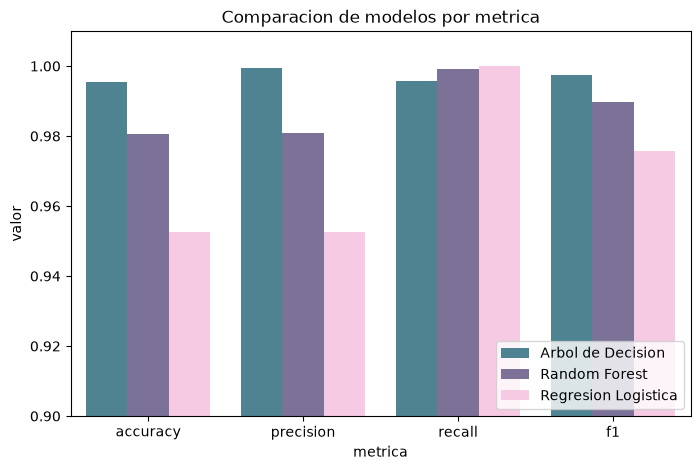

In [8]:
plt.figure(figsize=(8, 5))
resultados_melted = resultados.melt(id_vars='modelo', var_name='metrica', value_name='valor')

colores = {
    'Arbol de Decision': '#448A9C',      # azul
    'Random Forest': '#796C9D',          # naranja
    'Regresion Logistica': '#FFC2E5'     # verde
}

sns.barplot(data=resultados_melted, x='metrica', y='valor', hue='modelo', palette=colores)
plt.title('Comparacion de modelos por metrica')
plt.ylim(0.9, 1.01)
plt.legend(loc='lower right')
plt.show()

## Conclusiones de la evaluacion

Se entrenaron y evaluaron 3 modelos de clasificacion binaria sobre el dataset de solicitudes de credito, con el objetivo de predecir si el cliente paga a tiempo (`Pago_atiempo`).

**Resultados obtenidos:**

| Modelo | Accuracy | Precision | Recall | F1-score |
|---|---|---|---|---|
| Arbol de Decision | 0.9954 | 0.9995 | 0.9956 | 0.9976 |
| Random Forest | 0.9805 | 0.9809 | 0.9990 | 0.9899 |
| Regresion Logistica | 0.9526 | 0.9526 | 1.0000 | 0.9757 |

**Modelo seleccionado: Arbol de Decision**, por presentar el mejor desempeno general (mayor f1-score y accuracy), superando a Random Forest y a Regresion Logistica en la mayoria de las metricas.

**Observacion importante:** el Recall de 1.0000 obtenido por la Regresion Logistica es sospechoso, ya que el dataset presenta un fuerte desbalance de clases (aproximadamente 95% de los clientes paga a tiempo). 
Esto sugiere que dicho modelo podria estar prediciendo la clase mayoritaria de forma poco discriminativa, en lugar de aprender un patron real. 
Esta hipotesis se podria confirmar en una iteracion futura analizando la matriz de confusion de cada modelo.

In [12]:
import joblib
joblib.dump(arbol, r'C:\Users\agust\Desktop\codigos1\M5\PIM5\mlops_pipeline\src\modelo_arbol.pkl')
print("Modelo guardado correctamente")

Modelo guardado correctamente
